# 02. File and Directory Manipulation

## 1. Creating, Copying, Moving and Deleting File Directories

### 1.1 Create a Directory:

Write a Bash script that creates a directory named "workarea" in the current directory.

In [ ]:
#!/bin/bash

mkdir -p workarea

* `#!/bin/bash` -> shebang, tells the system to run this script using the Bash shell.
*  `mkdir workarea` -> Creates a directory called `workarea` in the current working directory.

In [ ]:
#!/bin/bash

mkdir -p workarea

* `-p` ensures:
  * No error if `workarea` already exists
  * Parent directories are created if needed

### 1.2 Copy a File:

Write a Bash script that copies a file named "error.log" to a new file named "old_error.log".

In [ ]:
cp error.log old_error.log

* `cp error.log old_error.log` -> Copies the file `error.log` and creates a new file called `old_error.log`.

In [ ]:
#!/bin/bash

if [ -f "error.log" ]; then
    cp error.log old_error.log
    echo "File copied successfully."
else
    echo "Error: error.log does not exist."
fi

* `-f` ensures the source is a regular file
* Prevents silent failure and gives clear feedback

In [ ]:
#!/bin/bash

cp -n error.log old_error.log

* `-n` -> avoids overwriting an existing `old_error.log`.

### 1.3 Move a Directory:

Write a Bash script that moves a directory named "workarea" to a new location named "new_workarea".

In [ ]:
#!/bin/bash

mv workarea new_workarea

* `mv workarea new_workarea` -> Renames or moves the directory `workarea` to `new_workarea` in the same parent directory.

In [ ]:
#!/bin/bash

if [ -d "workarea" ]; then
    mv workarea new_workarea
    echo "Directory moved successfully."
else
    echo "Error: workarea directory does not exist."
fi

* `-d` ensures the target is a directory
* Prevents errors if the directory is missing

### 1.4 Delete a File:

Write a Bash script that deletes a file named "file1.txt".

In [ ]:
#!/bin/bash

rm file1.txt

* `rm file.txt` -> Permanently deletes the file `file1.txt`

In [ ]:
#!/bin/bash

if [ -f "file1.txt" ]; then
    rm file1.txt
    echo "file1.txt deleted successfully."
else
    echo "Error: file1.txt does not exist."
fi

This version checks that the file exists before deleting it.

In [ ]:
#!/bin/bash

rm -i file1.txt
rm -f file1.txt

* `-i` -> Prompt before deleting
* `-f` -> Suppress error messages if missing

### 1.5 Create Multiple Directories:

Write a Bash script that creates three directories named "dir_1", "dir_2", and "dir_3" in the current directory.

In [ ]:
#!/bin/bash

mkdir -p dir_1 dir_2 dir_3

* `mkdir -p dir_1 dir_2 dir_3`
  * Creates all three directories in one command.
  * `-p` prevents errors if the directories already exist

In [ ]:
#!/bin/bash

for i in 1 2 3; do
    mkdir -p "dir_$i"
done

### 1.6 Copy Multiple Files:

Write a Bash script that copies all files with the ".txt" extension from one directory to another.

In [ ]:
#!/bin/bash

cp source_dir/*.txt destination_dir/

* `cp` -> copy command
* `source_dir/*.txt` -> matches all files ending with `.txt` in `source_dir`
* `destination_dir/` -> target directory directory where files are copied

In [ ]:
#!/bin/bash

SRC="source_dir"
DEST="destination_dir"

if [ -d "$SRC" ] && [ -d "$DEST" ]; then
  if ls "$SRC"/*.txt 1> /dev/null 2>&1; then
    cp "$SRC"/*.txt "$DEST"/
    echo "Text files copied successfully."
  else
    echo "No .txt files found in $SRC."
  fi
else
  echo "Error: Source or destination directory does not exist."
fi

This version checks that both directories exist and that `.txt` files are present.

In [ ]:
cp -r source_dir/*.txt destination_dir/ # Copy recursively (including subdirectories)
cp -i source_dir/*.txt destination_dir/ # Prompt before overwriting files
cp -p source_dir/*.txt destination_dir/ # Preserve timestamps and permissions

### 1.7 Move Multiple Directories:

Write a Bash script that moves multiple directories named "dir1", "dir2", and "dir3" to a new location named "new_dir".

In [ ]:
#!/bin/bash

mv dir1 dir2 dir3 new_dir

* `mv` -> moves files or directories
* `dir1 dir2 dir3` -> directories to move
* `new_dir/` -> destination directory (must exist)

In [ ]:
#!/bin/bash

DEST="new_dir"

if [ -d "$DEST" ] && [ -d "dir1" ] && [ -d "dir2" ] && [ -d "dir3" ]; then
  mv dir1 dir2 dir3 "$DEST"/
  echo "Directories moved successfully."
else
  echo "Error: One or more source directories or destination directory is missing."
fi

In [ ]:
#!/bin/bash

mkdir -p new_dir
mv dir1 dir2 dir3 new_dir/

* `new_dir` must exist (or be created) before the move
* If directories with the same names already exist in `new_dir`, they may be overwritten or merged.

### 1.8 Delete Multiple Files:

Write a Bash script that deletes all files with names starting with "error" in the current directory.

In [ ]:
#!/bin/bash

rm error*

* `rm` -> removes files
* `error*` -> matches any file starting with `error` (e.g. `error.log`, `error1.txt`, `error_backup`)

In [ ]:
#!/bin/bash

rm -i error* # prompt before each deletion

In [ ]:
#!/bin/bash

# Ensures only regular files are deleted (not directories)
for f in error*; do
    [ -f "$f" ] && rm "$f"
done

### 1.9 Write a Directory Hierarchy:

Write a Bash script that creates a directory hierarchy with the following structure:

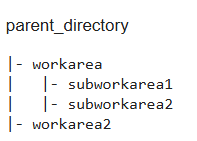

In [ ]:
mkdir -p parent_directory/workarea/subworkarea1
mkdir -p parent_directory/workarea/subworkarea2
mkdir -p parent_director/workarea2

* `-p` -> creates parent directories automatically if they don't exist
* `-p` -> prevents errors if directories already exist

### 1.10 Copy Directory Contents:

Write a Bash script that copies all files and subdirectories from one directory to another, preserving the directory structure.

In [ ]:
#!/bin/bash

cp -r source_dir/ destination_dir/

* `cp` -> copy command
* `-r` -> recursively copy all files and subdirectories
* `source_dir/` -> everything inside this directory
* `destination_dir/` -> target directory (must exist)

In [ ]:
#!/bin/bash

# Preserving permissions, timestamps, links)
cp -a source_dir/. destination_dir/

* `-a` (archive) preserves:
  * permissions
  * ownership
  * timestamps
  * symbolic links
* `source_dir/.` ensures hidden files are included

In [ ]:
#!/bin/bash

rsync -a source_dir/ destination_dir/

* Handles large directories efficiently
* Preserves structure and metadata
* Resumable if interrupted

## 2. Listing Files and Directories

### 2.1
Write a Bash script that lists all files and directories in the current directory.

In [ ]:
#!/bin/bash

ls

* `ls` -> stands for list
* `ls` -> displays all files and directories in the current working directory
* `ls` -> hidden files are not shown, output is shown in columns

In [ ]:
#!/bin/bash

ls -la

* `-a` -> all, including hidden files
* `-l` shows:
  * file permissions
  * number of links
  * owner
  * group
  * file size
  * last modified date
  * file/directory name

### 2.2 
Write a Bash script that lists only the files in the current directory.

In [ ]:
#!/bin/bash

# Bash script to list only files in the current directory
for file in *; do
    if [ -f "$file" ]; then
        echo "$file"
    fi
done

1. `for file in *; do`
   * `*` is a glob pattern
   * It expands to all entries in the current directory:
     * regular files
     * directories
     * symlinks
   * Each entry is assigned to the variable `file`, one at a time
2. `if [ -f "$file" ]; then`
   * `[ -f "$file" ]` is a test expression
   * `-f` checks:
     * `true` -> regular file
     * `false` -> directory, symlink, device, etc.
   * Quoting `"$file"` is very important
     * handles filenames with spaces
     * prevents word splitting and globbing bugs
3. `echo "$file"`
   * Prints the filename only if it is a regular file
4. `done`
   * Ends the loop

### 2.3 
Write a Bash script that lists only the directories in the current directory.

In [ ]:
#!/bin/bash

# Bash script to list only directories in the current directory
for item in *; do
    if [ -d "$item" ]; then
        echo "$item"
    fi
done

1. `for item in *; do`
   * `*` is a glob pattern
   * Expands to all entries in the current directory:
     * files
     * directories
     * symbolic links
   * Each entry is stored in the variable `item`
2. `if [ -d "$item" ]; then`
   * `[ -d "$item" ]` checks whether the entry is a directory
   * Returns true only for directories
   * Quoting `"$item"` is important:
     * handles spaces in directory names
     * prevents word splitting
3. `echo "$item"
   * Prints the directory name when the test condition is true
4. `done`
   * Ends the loop

### 2.4 
Write a Bash script that lists all files and directories in a specific directory provided as an argument to the script.

In [ ]:
#!/bin/bash

# Check if a directory argument is provided
if [ $# -eq 0 ]; then
    echo "Usage: $0 <directory>"
    exit 1
fi

DIR="$1"

# Check if the argument is a valid directory
if [ -d "$DIR" ]; then
    ls "$DIR"
else
    echo "Error: '$DIR' is not a valid directory."
    exit 1
fi

1. `$#`
   * `$#` stores the number of arguments passed to the script
   * `[ $# -eq 0 ]` checks if no argument was provided
2. `"$0"`
   * `$0` -> name of the script itself
   * Used to show correct usage instructions
3. `DIR="$1"
   * `$1` is the first positional argument
   * Stores the directory path provided by the user
4. `[ -d "$DIR" ]`
   * `-d` checks whether ethe argument exsits and is a directory
   * Prevents errors when `ls` is run
5. `ls "$DIR"`
   * Lists all fies and directories inside the given directory
   * Quoting allows paths with spaces

### 2.5 
Write a Bash script that lists all hidden files (files starting with a dot) in the current directory.

In [ ]:
#!/bin/bash

for file in .[^.]*; do
    [ -f "$file" ] && echo "$file"
done

1. `.[^.]*`
   * Used to match hidden entries, while excluding special directories
     * `.` - The filename must start with a dot (hidden file)
     * `[^.]` - The second character must not be a dot
     * `*` - Match the rest of the filename
2. `for file in ...; do`
   * Iterates over each filename matched by the glob
   * Each match is stored in the variable `file`
   * Bash performs globbing before the loop runs
3. `[ -f "$file" ]`
   * `-f` checks whether the entry is a regular file
   * Exlcudes:
     * directories
     * symlinks
     * device files
4. `&&`
   * Runs the second command only if the first succeeds
   * If the file is a regular file, its name is printed

### 2.6 
Write a Bash script that lists all files modified within the last 24 hours in the current directory.

In [ ]:
#!/bin/bash

find . -maxdepth 1 -type f -mtime -1

1. `find` ->searches the filesystem based on conditions
2. `.` -> Tells `find` to start searching in the current directory
3. `-maxdepth 1`
   * Limits the search to only the current directory
   * Prevents recursion into subdirectories
4. `-type f`
   * selects regular files only
   * Excludes:
     * directories
     * symlinks
     * device files
5. `-mtime -1`
   * Filters files based on modification time
   * `-1` means:
     * modified less than 1 day ago
     * i.e within the last 24 hours

### 2.7 
Write a Bash script that lists all files larger than 1MB in the current directory.

In [ ]:
#!/bin/bash

find . -maxdepth 1 -type f -size +1M

1. `-size +1M`
   * Filters files by size
   * `+1M` means greater than 1 megabyte
   * `M` = 1,048,576 bytes (binary MB)

### 2.8 
Write a Bash script that lists all empty files in the current directory.

In [ ]:
#!/bin/bash

find . -maxdepth 1 -type f -empty

1. `-empty`
   * Matches files with zero size (0 bytes)
   * Also works for empty directories, but:
     * combined with `-type f`, it selects only empty files

### 2.9 
Write a Bash script that lists all files with a specific extension (e.g., ".txt") in the current directory.

In [7]:
#!/bin/bash

for file in ~/linux/linux-bash-notebooks/materials/*.txt; do
    [ -f "$file" ] && echo "$file"
done

/home/hladmin/linux/linux-bash-notebooks/materials/document.txt
/home/hladmin/linux/linux-bash-notebooks/materials/file1.txt
/home/hladmin/linux/linux-bash-notebooks/materials/file2.txt
/home/hladmin/linux/linux-bash-notebooks/materials/input.txt
/home/hladmin/linux/linux-bash-notebooks/materials/nums.txt
/home/hladmin/linux/linux-bash-notebooks/materials/output.txt
/home/hladmin/linux/linux-bash-notebooks/materials/sample.txt
/home/hladmin/linux/linux-bash-notebooks/materials/test.txt


## 3. Searching for Files 

### 3.1 
Write a Bash script that searches for a file named "output.txt" in the current directory.

In [ ]:
#!/bin/bash

find . -maxdepth 1 -name "output.txt"

* `name "output.txt"
  * Searches for files exactly named `output.txt`
  * Case-sensitive by default

### 3.2 
Write a Bash script that searches for a file with a specific name provided as an argument to the script.

In [ ]:
#!/bin/bash

if [ $# -eq 0 ]; then
    echo "Usage: $0 <filename>"
    exit 1
fi

FILENAME="$1"

find . maxdepth 1 -type f -name "$FILENAME"

1. `$#` - number of arguments
   * `$#` stores how many arguments were passed to the script
   * `[ $# -eq 0 ]` checks that at least one argument is provided
2. `"$0"` - script name
   * `$0` expands to the name of the script
   * Used to print a helpful usage message
3. `FILENAME="$1"`
   * `$1` is the first positional argument
   * Stores the filename to search for

### 3.3 
Write a Bash script that searches for files modified within the last 3 days in the current directory.

In [8]:
#!/bin/bash

find . -maxdepth 1 -type f -mtime -3

./02_file_directory_manipulation.ipynb


### 3.4 
Write a Bash script that searches for files larger than 1KB in the current directory.

In [ ]:
#!/bin/bash

find . -maxdepth 1 -type f -size +1k

* `-size +1k`:
    * Filters files based on size
    * `+1k` means greather than 1 kilobyte
    * `k` represents 1024 bytes

### 3.5 
Write a Bash script that searches for empty files in the current directory.

In [ ]:
#!/bin/bash

find . -maxdepth 1 -type f -empty

1. `-empty`
   * Matches files with zero size (0 bytes)
   * When combined with `-type f`, ensures only empty files are returned.

### 3.6 
Write a Bash script that searches for files with a specific extension (e.g., "txt") in the current directory.

In [ ]:
#!/bin/bash

for file in *.txt; do
    [ -f "$file" ] && echo "file"
done

1. `*.txt` - glob pattern
   * `*` -> matches any number of characters
   * `.txt` -> matches files ending with `.txt`
2. `for file in *.txt; do`
   * Iterates over each `.txt` entry
   * Each filename is stored in the variable `file`
3. `[ -f "$file" ]`
   * Ensures the match is a regular file
   * Prevents accidental output of directories or special files

### 3.7 
Write a Bash script that searches for files containing a specific string provided as an argument to the script.

In [ ]:
#!/bin/bash

if [ $# -eq 0 ]; then
    echo "Usage: $0 <search_string>"
    exit 1
fi

SEARCH_STRING="$1"

grep -l "$SEARCH_STRING"

1. `$#` - number of arguments
   * `$#` stores the number of arguments passed to the script
   * Ensures the user provides a search string
2. `$0` - script name
   * `$0` expands to the script's name
   * Used to display correct usage instructions
3. `SEARCH_STRING="$1"`
   * `$1` is the first positional argument
   * Stores the string to search for
   * Quoting allows spaces in the search string
4. `grep -l "$SEARCH_STRING" *`
   * `grep` -> searches file contents
   * `-l` -> prints only filenames that contain the string
   * `"$SEACH_STRING"` -> text to search for
   * `*` -> searches all files in the current directory

### 3.8 
Write a Bash script that searches for files owned by a specific user in the current directory.

In [ ]:
#!/bin/bash

if [ $# -eq 0 ]; then
    echo "Usage: $0 <username>"
    exit
fi

USERNAME="$1"

find . -maxdepth 1 -type f -user "$USERNAME"

* `-user "$USERNAME"`
  * Filters files by owner
  * Matches files owned by the specified user
  * Uses system user information (`/etc/passwd`)

### 3.9 
Write a Bash script that searches for symbolic links in the current directory.

In [ ]:
#!/bin/bash

find . -maxdepth 1 -type l

* `-type l`
  * Matches symbolic links
  * `l` stands for link
  * Excludes:
    * regular files
    * directories
    * device files

### 3.10 
Write a Bash script that searches for files with execute permissions in the current directory.

In [ ]:
#!/bin/bash

find . -maxdepth 1 -type f -executable

1. `-executable`
   * Mathces files that have the execute permission
   * Checks whether the current user can execute the file
   * More reliable than parsing permission strings

## 4 Changing File Permissions

### 4.1 
Write a Bash script that sets the permissions of a file named "output.txt" to read, write, and execute for the owner, read and write for the group, and read-only for others.

In [ ]:
#!/bin/bash

chmod 764 output.txt

1. `chmod`
   * `chmod` stands for change mode
   * It is used to modify file permissions in Linux

In [ ]:
#!/bin/bash

chmod u=rwx,g=rw,o=r output.txt

* `u` -> owner
* `g` -> group
* `o` -> others

### 4.2 
Write a Bash script that removes write permissions for the group and others from a file named "input.txt".

In [ ]:
#!/bin/bash

chmod go-w input.txt

1. `go-w` -> symbolic mode, which modifies permissions incrementally.
   * `g` - > group
   * `o` -> others
   * `go` -> group and others
   * `-` -> remove permission
   * `w` -> write permission

In [ ]:
#!/bin/bash

chmod 644 input.txt

### 4.3 
Write a Bash script that grants execute permissions to all users for a script named "test.sh".

In [ ]:
#!/bin/bash

chmod a+x test.sh

2. `a+x`
   * `a` -> all users (owner, group, others)
   * `+` -> add permission
   * `x` -> execute permission

### 4.4 
Write a Bash script that sets the permissions of a directory named "workarea" to read, write, and execute for the owner, read and execute for the group, and no permissions for others.

In [ ]:
#!/bin/bash

chmod 750 workarea

1. Numeric (octal) permission `750` -> Each digit represents permissions for a user class:
|Digit|User class|Permissions|Binary|Meaning|
|---|---|---|---|---|
|`7`|Owner|read + write + execute|111|`rwx`|
|`5`|Group|read + execute|101|`r-x`|
|`0`|Others|no permissions|000|`---`|

3. Why execute (`x`) matters on directories
   * `r` -> list directory contents
   * `x` -> access (enter) the directory
   * `w` -> create/delete files inside the directory


### 4.5 
Write a Bash script that removes all permissions for the group and others from a directory named "parent_directory".

In [ ]:
#!/bin/bash

chmod go-rwx parent_directory

### 4.6 
Write a Bash script that grants read and write permissions to the owner, group, and others for a file named "output.txt".

In [ ]:
#!/bin/bash

chmod 666 output.txt

### 4.7 
Write a Bash script that removes execute permissions for the owner and group from a script named " my_script.sh".

In [ ]:
#!/bin/bash

chmod ug-x my_script.sh

### 4.8 
Write a Bash script that grants read, write, and execute permissions to the owner and group, and read-only permission for others for a directory named "workarea".

In [ ]:
#!/bin/bash

chmod 774 workarea

### 4.9 
Write a Bash script that removes read and write permissions for the group from a file named "input.txt".

In [ ]:
#!/bin/bash

chmod g-rw input.txt

### 4.10 
Write a Bash script that grants read, write, and execute permissions to the owner, and read-only permissions for others for a script named "my_script.sh".

In [ ]:
#!/bin/bash

chmod 744 my_script.sh

## 5. Archiving and Compressing Files

### 5.1 Create a Tar Archive:

Write a Bash script that creates a tar archive of a directory named "workarea".

In [ ]:
#!/bin/bash

tar -cvf workarea.tar workarea

1. `tar`
   * `tar` stands for tape archive
   * Used to bundle multiple files and directories into a single archive
2. Options used: `-cvf`
   * `-c` -> create a new archive
   * `-v` -> verbose (shows files being archived)
   * `-f` -> specify archive filename

### 5.2 Extract a Tar Archive:

Write a Bash script that extracts the contents of a tar archive named 'workarea.tar' into a directory named "extracted_files".

In [ ]:
#!/bin/bash

mkdir -p extracted_files

tar -xvf workarea.tar -C extracted_files

1. `tar -xvf workarea.tar -C extracted_files`
   * `-x` -> extract files
   * `-v` -> verbose output
   * `-f` -> specify archive file
   * `-C` -> change to directory before extracting

### 5.3 Create a Gzip Compressed Archive:

Write a Bash script that creates a gzip compressed archive of a directory named "workarea".

In [ ]:
#!/bin/bash

tar -czvf workarea.tar.gz workarea

1. Options used: `-czvf`
   * `-c` -> create a new archive
   * `-z` -> compress using gzip
   * `-v` -> verbose
   * `-f` -> specify archive filename

### 5.4 Extract a Tar Archive:

Write a Bash script that extracts the contents of a tar archive named "workarea.tar.gz" into a directory named "extracted_files".

In [ ]:
#!/bin/bash

mkdir -p extracted_files

tar -xzvf workarea.tar.gz -C extracted_files

1. `tar -xzvf workarea.tar.gz -C extracted_files`
   * `-x` -> extract files
   * `-z` -> decompress gzip archive
   * `-v` -> verbose output
   * `-f` -> specify archive file
   * `-C` -> change to directory before extracting

### 5.5 Create a Zip Archive:

Write a Bash script that creates a zip archive of a directory named "workarea".

In [ ]:
#!/bin/bash

zip -r workarea.zip workarea

1. `zip` -> used to create ZIP archives
2. Options used: `-r`
   * `-r` -> recursive
   * Ensures all files and subdirectories inside `workarea` are included
3. Archive name and source
   * `workarea.zip` -> output archive
   * `workarea` -> directory being archived
   * Directory structure is preserved inside the ZIP

### 5.6 Extract a Zip Archive:

Write a Bash script that extracts the contents of a zip archive named "workarea.zip" into a directory named "new_dir".

In [ ]:
#!/bin/bash

mkdir -p new_dir

unzip workarea.zip -d new_dir

1. `mkdir -p new_dir`
   * Creates the directory `new_dir` if it doesn't already exist
   * `-p` prevents errors if the directory already exists
2. `unzip workarea.zip -d new_dir`
   * `unzip` -> extracts ZIP archives
   * `workarea.zip` -> ZIP archive to extract
   * `-d new_dir` -> destination directory

### 5.7 Create a Tar Archive Excluding Specific Files:

Write a Bash script that creates a tar archive of a directory named "source_directory", excluding files with a ".txt" extension.

In [ ]:
#!/bin/bash

tar --exclude='*.txt' -cvf source_directory.tar source_directory

1. `--exclude='*.txt'`
   * Tells `tar` to skip all files ending with `.txt`
   * The pattern applies:
     * to files in the directory
     * and to files in subdirectories
   * Quoting `'*.txt'` prevents the shell from expanding the wildcard too early
2. Options: `-cvf`
   * `-c` -> create a new archive
   * `-v` -> verbose output
   * `-f` -> specify archive name
3. `source_directory
   * The directory being archived
   * Directory structure is preserved, except for excluded files

### 5.8 Compress Multiple Files into a Single Gzip Compressed File:

Write a Bash script that compresses multiple files (e.g., file1.txt, file2.txt) into a single gzip compressed file named "compressed_files.tar.gz".

In [ ]:
#!/bin/bash

tar -czvf compressed_files.tar.gz file1.txt file2.txt

1. Options used: `-czvf`
   * `-c` -> create a new archive
   * `-z` -> compress using gzip
   * `-v` -> verbose
   * `-f` -> specify archive filename
2. Files to compress: `file1.txt file2.txt`
   * List any number of files
   * Order does not matter

### 5.9 Extract Specific Files from a Tar Archive:

Write a Bash script that extracts specific files (e.g., file1.txt, file2.txt) from a tar archive named "archive.tar.gz" into a directory named "extracted_files".

In [ ]:
#!/bin/bash

mkdir -p extracted files

tar -xzvf archive.tar.gz -C extracted_files file1.txt file2.txt

1. `tar -xzvf archive.tar.gz -C extracted_files file1.txt file2.txt`
   * `-x` -> extract files
   * `-z` -> decompress gzip archive
   * `-v` -> verbose output
   * `-f` -> specify archive file
   * `-C` -> change to directory before extracting
   * `file1.txt file2.txt` specifies only the files to extract
   * Files are extracted only if they exist inside the archive

### 5.10 Compress a Directory into a Zip Archive with Password Protection:

Write a Bash script that compresses a directory named "workarea" into a zip archive named "archive.zip" with password protection.

In [ ]:
#!/bin/bash

zip -r -e archive.zip workarea

1. Options used: `-r -e`
   * `-r` -> recursively include all files and subdirectories
   * `-e` -> Enable encryption (prompts for a password)

## 6. Working with Symbolic Links

### 6.1 Create a Symbolic Link:

Write a Bash script that creates a symbolic link named "file_link" pointing to a file named "input.txt".

In [ ]:
#!/bin/bash

ln -s input.txt file_link

1. `ln` -> used to create links between files
2. `-s` (symbolic link)
   * `-s` creates a symbolic (soft) link
   * Unlink hard links, symbolic links:
     * can point to directories
     * can point across filesystems
     * store the path to the target file
3. `input.txt`
   * The target file
   * The symbolic link will reference this file
4. `file_link`
   * The name of the symbolic link being created
   * Accessing `file_link` accesses `input.txt`

### 6.2 Check if a Symbolic Link Exists:

Write a Bash script that checks if a symbolic link named "file_link" exists in the current directory.

In [ ]:
#!/bin/bash

if [ -L "file_link" ]; then
    echo "Symbolic link 'file_link' exists."
else
    echo "Symbolic link 'file_link' does not exist."
fi

1. `[ -L "file_link" ]`
   * `-L` tests whether the path is a symbolic link
   * Returns true even if the link is broken

### 6.3 Remove a Symbolic Link:

Write a Bash script that removes a symbolic link named "file_link".

In [ ]:
#!/bin/bash

rm file_link

1. `rm`
   * `rm` removes files and symbolic links
   * Removing a symbolic link does not delete the target file
   * Only the link itself is removed
2. `file_link`
   * This is the name of the symbolic link
   * The target file remains untouched

### 6.4 Create a Symbolic Link for a Directory:

Write a Bash script that creates a symbolic link named "dir_link" pointing to a directory named "workarea".

In [ ]:
#!/bin/bash

ln -s workarea dir_link

1. `ln` -> used to create links
2. `-s` -> creates a symbolic link
3. `wokarea`
   * The target directory
   * Must exist for the link to be valid
4. `dir_link`
   * The name of the symbolic link being created
   * Accessing `dir_link` behaves as if you are accessing `workarea`

### 6.5 Check if a Symbolic Link Points to a Directory:

Write a Bash script that checks if a symbolic link named "dir_link" points to a directory.

In [ ]:
#!/bin/bash

if [ -L "dir_link" ] && [ -d "dir_link" ]; then
    echo "dir_link is a symbolic link pointing to a directory."
else
    echo "dir_link does not point to a directory."
fi

1. `[ -L "dir_link" ]`
   * `-L` checks whether `dir_link` is a symbolic link
   * Returns true even if the link is broken
2. `[ -d "dir_link" ]`
   * `-d` checks whether the path refers to a directory
   * When used on a symbolic link:
     * It follows the link
     * Returns true only if the target is a directory
3. `&&` (logical AND)
   * Both conditions must be true:
     1. `dir_link` is a symbolic link
     2. The link points to a directory

### 6.6 List Symbolic Links in the Current Directory:

Write a Bash script that lists all symbolic links in the current directory.

In [ ]:
#!/bin/bash

find . -maxdepth 1 -type l

1. `find`
   * Searches the filesystem based on file attributes
   * Best tool for identifying file types in scripts
2. `.` (current directory) -> Starts the search in the current directory
3. `-maxdepth 1`
   * Limits the search to only the current directory
   * Prevents recursion into subdirectories
4. `-type l`
   * Matches symbolic links
   * `l` stands for link
   * Excludes regular files and directories

### 6.7 Determine the Target of a Symbolic Link:

Write a Bash script that prints the target of a symbolic link named "file_link".

In [ ]:
#!/bin/bash

if [ -L "file_link" ]; then 
    readlink file_link
else
    echo "file_link is not a symbolic link."
fi

1. `[ -L "file_link" ]`
   * `-L` checks whether `file_link` is a symbolic link
   * Returns true even if the link is broken
   * Prevents errors if the file is not a symlink
2. `readlink file_link`
   * `readlink` prints the path that the symbolic link points to

### 6.8 Create a Symbolic Link with Absolute Path:

Write a Bash script that creates a symbolic link named "link_to_file" with an absolute path pointing to a file named "input.txt".

In [ ]:
#!/bin/bash

TARGET_FILE="$(pwd)/input.txt"
ln -s "$TARGET_FILE" link_to_file

1. `$(pwd)`
   * `pwd` prints the absolute path of the current directory
   * Command substitution `$(...)` captures that output
2. `TARGET_FILE="$(pwd)/input.txt"
   * Constructs the absolute path to `input.txt`
   * Using quotes ensures safety if the path contains spaces
3. `ln -s "$TARGET_FILE" link_to_file`
   * `ln` -> create a link
   * `-s` -> symbolic (soft) link
   * `$TARGET_FILE"` -> absolute path to the target file
   * `link_to_file` -> name of the symbolic link

### 6.9 Create a Symbolic Link with Relative Path:

Write a Bash script that creates a symbolic link named "link_to_file1" with a relative path pointing to a file named "output.txt".

In [ ]:
#!/bin/bash

ln -s output.txt link_to_file1

1. Relative path: `output.txt`
   * `output.txt` is a relative path
   * The path is interpreted relative to the location of the symbolic link
   * This makes the link portable if the whole directory is moved together
2. `ln -s`
   * `ln` -> create a link
   * `-s` -> symbolic (soft) link
3. `link_to_file1`
   * Name of the symbolic link being created
   * Accessing `link_to_file1` accesses `output.txt`

### 6.10 Create a Symbolic Link to a Common System Directory:

Write a Bash script that creates a symbolic link named "link_to_bin1" pointing to the "/bin" directory.

In [ ]:
#!/bin/bash

ln -s /bin link_to_bin1

1. `/bin`
   * `/bin` is a system directory containing essential binaries (e.g., `ls`, `cp`, `cat`)
   * The path is absolute, so the link will work regardless of location
2. `ln -s`
   * `ln` -> create a link
   * `-s` -> symbolic (soft) link
   * Required when linking to directories like `/bin`
3. `link_to_bin1`
   * Name of the symbolic link being created
   * Accessing `link_to_bin1` behaves the same as accessing `/bin`